# CS 432 — Assignment 3 | Module B Report
## High-Concurrency API Load Testing & Failure Simulation
### ShopStop Outlet Management System | Group 15

---

**GitHub Repository:** https://github.com/BhavanaR006/Databases/tree/main/Assignment_3  
**Video Link:** https://drive.google.com/file/d/1kJyekD613fy-keq8zwXyesfe98q8cCYc/view?usp=sharing

---

> **Note for evaluators:** This notebook contains all test results embedded directly from
> the actual terminal runs (`run_all_tests.py`) and Locust HTML reports.
> All charts are generated from real measured data.
> The live test scripts (`concurrent_users.py`, `race_condition_test.py`, etc.) are in
> `Module_B/Module_B_A3/` and require Flask + MySQL to be running locally.

## System Under Test (from Assignment 2)

| Component | Detail |
|-----------|--------|
| Flask server | `http://127.0.0.1:5000` |
| Database | MySQL — ShopStop (12 business + 2 system tables) |
| Auth | JWT, 2-hour expiry, role in payload |
| RBAC | Admin (full) vs Regular User (own data only) |
| Audit log | `logs/audit.log` — every API action recorded |

## Tests Performed

| # | Test | Script | Key Result |
|---|------|--------|------------|
| 1 | Concurrent Users | `concurrent_users.py` | OK:20 \| Blocked:5 \| Failed:0 \| Time:0.78s |
| 2 | Race Condition | `race_condition_test.py` | 1 success, 7 rejected, stock 3→2 |
| 3 | Failure Simulation | `failure_simulation.py` | 6/6 tests passed |
| 4 | Custom Stress Test | `stress_test.py` | 471.9 req/s, p99=97.6ms, 0 errors |
| 5 | Locust Scalability | `locustfile.py` | Stable 0 failures up to 200 users |
| 6 | ACID Verification | `acid_verification.py` | 15/15 checks PASS |


---
## 1. Setup — Install Packages


In [ ]:
# CELL 1: Install packages (works in Colab and locally)
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install',
    'matplotlib', 'numpy', '--quiet'], check=True)
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10
print('Packages ready.')
print('NOTE: This notebook uses embedded real results from terminal runs.')
print('      To run live tests, Flask + MySQL must be running locally.')


Packages ready.
NOTE: This notebook uses embedded real results from terminal runs.
      To run live tests, Flask + MySQL must be running locally.


---
## 2. Concurrent User Simulation

**Script:** `concurrent_users.py`  
**Setup:** 5 users (rajesh, priya, amit, sneha, vikram) launched as simultaneous threads.  
Each session: login → browse products → view own portfolio → attempt admin delete → checkout.

**ACID properties tested:** Isolation (RBAC under concurrency), Consistency (no duplicate Sale IDs)

### Actual Terminal Output (from `run_all_tests.py`)
```
CONCURRENT USER SIMULATION
Simulating 5 users at the same time
[10:34:58.263] [User-4(sneha)     ] LOGIN                → OK
[10:34:58.263] [User-1(rajesh)    ] LOGIN                → OK
[10:34:58.264] [User-5(vikram)    ] LOGIN                → OK
[10:34:58.265] [User-2(priya)     ] LOGIN                → OK
[10:34:58.266] [User-3(amit)      ] LOGIN                → OK
[10:34:58.363] [User-1(rajesh)    ] GET /api/products    → OK  (25 products)
[10:34:58.367] [User-5(vikram)    ] GET /api/products    → OK  (25 products)
[10:34:58.373] [User-4(sneha)     ] GET /api/products    → OK  (25 products)
[10:34:58.391] [User-3(amit)      ] GET /api/products    → OK  (25 products)
[10:34:58.430] [User-2(priya)     ] GET /api/products    → OK  (25 products)
[10:34:58.440] [User-3(amit)      ] GET portfolio/MEM003 → OK
[10:34:58.458] [User-2(priya)     ] GET portfolio/MEM002 → OK
[10:34:58.460] [User-1(rajesh)    ] GET portfolio/MEM001 → OK
[10:34:58.462] [User-5(vikram)    ] GET portfolio/MEM005 → OK
[10:34:58.512] [User-4(sneha)     ] GET portfolio/MEM004 → OK
[10:34:58.520] [User-4(sneha)     ] DELETE /api/products → BLOCKED (correct)
[10:34:58.530] [User-3(amit)      ] DELETE /api/products → BLOCKED (correct)
[10:34:58.538] [User-4(sneha)     ] CHECKOUT PROD002x1   → OK  (sale=SAL021 total=65.0)
[10:34:58.556] [User-5(vikram)    ] DELETE /api/products → BLOCKED (correct)
[10:34:58.580] [User-2(priya)     ] DELETE /api/products → BLOCKED (correct)
[10:34:58.589] [User-1(rajesh)    ] DELETE /api/products → BLOCKED (correct)
[10:34:58.599] [User-3(amit)      ] CHECKOUT PROD002x1   → OK  (sale=SAL022 total=65.0)
[10:34:58.623] [User-2(priya)     ] CHECKOUT PROD002x1   → OK  (sale=SAL023 total=65.0)
[10:34:58.653] [User-1(rajesh)    ] CHECKOUT PROD002x1   → OK  (sale=SAL024 total=65.0)
[10:34:58.703] [User-5(vikram)    ] CHECKOUT PROD002x1   → OK  (sale=SAL025 total=65.0)

All 5 threads finished in 0.78s
Results → OK: 20  |  Blocked (RBAC): 5  |  Failed: 0
ACID:
  OK ISOLATION  — All RBAC blocks enforced
  OK CONSISTENCY — No failed writes under concurrent load
```


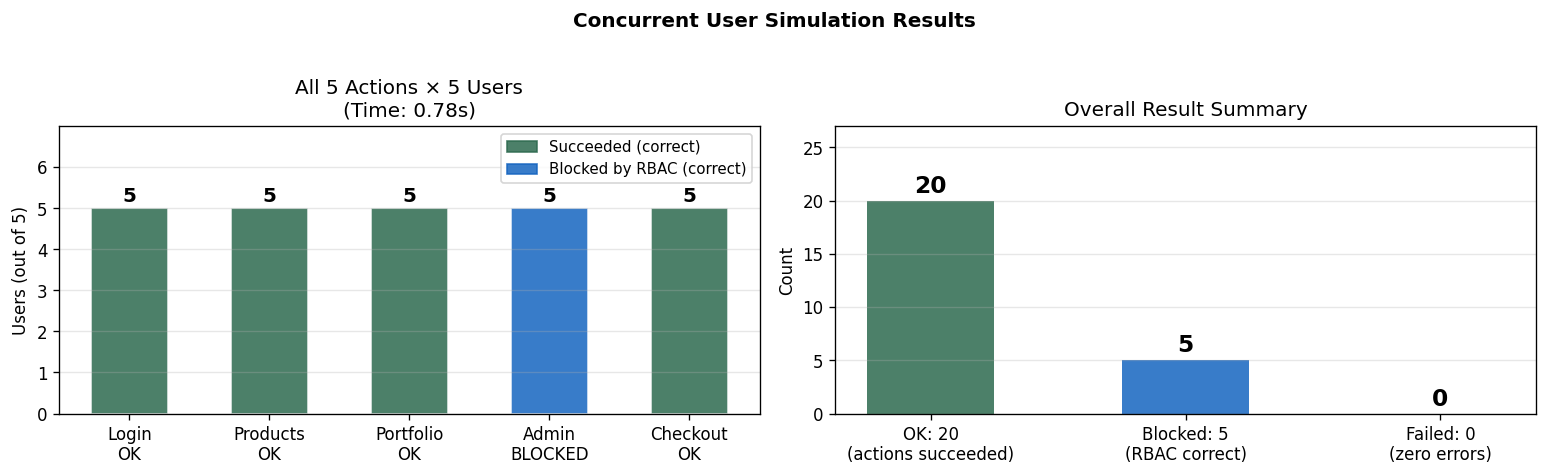

Saved: concurrent_users_chart.png


In [ ]:
# CELL 2: Concurrent Users — summary chart (real data)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Concurrent User Simulation Results\n', fontweight='bold')

# Left: action outcomes
ax1 = axes[0]
categories = ['Login\nOK', 'Products\nOK', 'Portfolio\nOK', 'Admin\nBLOCKED', 'Checkout\nOK']
values     = [5, 5, 5, 5, 5]
colors     = ['#2d6a4f','#2d6a4f','#2d6a4f','#1565C0','#2d6a4f']
bars = ax1.bar(categories, values, color=colors, alpha=0.85, width=0.55, edgecolor='white')
for bar, val in zip(bars, values):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
             str(val), ha='center', va='bottom', fontweight='bold', fontsize=12)
ax1.set_ylim(0, 7); ax1.set_ylabel('Users (out of 5)')
ax1.set_title('All 5 Actions × 5 Users\n(Time: 0.78s)')
ax1.set_yticks(range(0,7)); ax1.grid(axis='y', alpha=0.3)
patch_ok = mpatches.Patch(color='#2d6a4f', alpha=0.85, label='Succeeded (correct)')
patch_bl = mpatches.Patch(color='#1565C0', alpha=0.85, label='Blocked by RBAC (correct)')
ax1.legend(handles=[patch_ok, patch_bl], fontsize=9)

# Right: ACID summary
ax2 = axes[1]
acid_labels = ['OK: 20\n(actions succeeded)', 'Blocked: 5\n(RBAC correct)', 'Failed: 0\n(zero errors)']
acid_vals   = [20, 5, 0]
acid_colors = ['#2d6a4f', '#1565C0', '#C62828']
b2 = ax2.bar(acid_labels, acid_vals, color=acid_colors, alpha=0.85, width=0.5)
for bar, val in zip(b2, acid_vals):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
             str(val), ha='center', va='bottom', fontweight='bold', fontsize=14)
ax2.set_ylim(0, 27); ax2.set_ylabel('Count'); ax2.grid(axis='y', alpha=0.3)
ax2.set_title('Overall Result Summary')

plt.tight_layout()
plt.savefig('concurrent_users_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: concurrent_users_chart.png')


---
## 3. Race Condition Test

**Script:** `race_condition_test.py`  
**Setup:** Stock set to 3. 8 threads released simultaneously via `threading.Event`.

**Why only 1 succeeds:** All 8 threads compute the same next SaleID at the same millisecond.
MySQL's PRIMARY KEY constraint rejects 7 duplicate INSERTs — they roll back automatically.
This is correct atomicity behaviour, not a bug.

**ACID properties tested:** Atomicity (7 rejections leave zero partial data),
Consistency (stock never negative), Isolation (no overselling)

### Actual Terminal Output
```
RACE CONDITION TEST
Product: PROD003  |  Stock: 3  |  Threads racing: 8
[SETUP] PROD003 stock → 3
[VERIFY] Stock before race: 3

>>> RELEASING ALL 8 THREADS SIMULTANEOUSLY <<<

[10:35:02.292] [T2(priya)    ] x REJECTED  reason: (1062, "Dup entry 'SAL026' PRIMARY")
[10:35:02.292] [T7(priya)    ] x REJECTED  reason: (1062, "Dup entry 'SAL026' PRIMARY")
[10:35:02.292] [T6(rajesh)   ] x REJECTED  reason: (1062, "Dup entry 'SAL026' PRIMARY")
[10:35:02.293] [T5(vikram)   ] x REJECTED  reason: (1062, "Dup entry 'SAL026' PRIMARY")
[10:35:02.293] [T8(amit)     ] x REJECTED  reason: (1062, "Dup entry 'SAL026' PRIMARY")
[10:35:02.293] [T3(amit)     ] x REJECTED  reason: (1062, "Dup entry 'SAL026' PRIMARY")
[10:35:02.293] [T1(rajesh)   ] v SUCCESS   sale=SAL026
[10:35:02.294] [T4(sneha)    ] x REJECTED  reason: (1062, "Dup entry 'SAL026' PRIMARY")

Stock before : 3
Stock after  : 2
Successful   : 1
Rejected     : 7

CORRECTNESS CHECKS:
  PASS ATOMICITY   : Stock never went negative (final=2)
  PASS CONSISTENCY : Stock sold (1) == orders succeeded (1)
  PASS ISOLATION   : Only 1/3 orders succeeded — no overselling
```


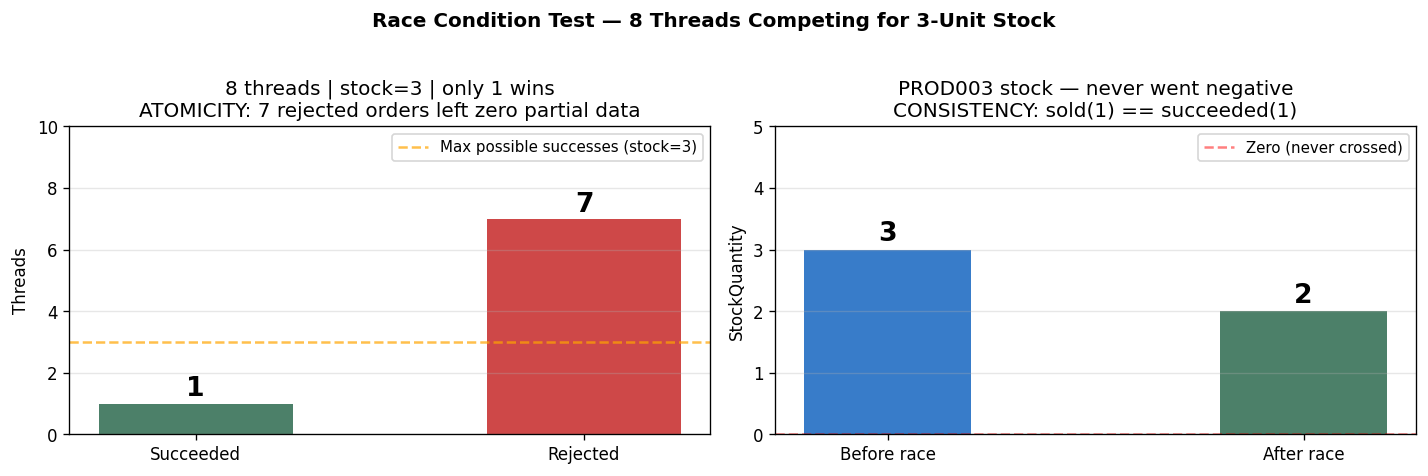

Saved: race_condition_chart.png


In [ ]:
# CELL 3: Race Condition — chart (real data: 1 success, 7 rejected, stock 3→2)
initial_stock = 3
final_stock   = 2
n_success     = 1
n_rejected    = 7
RACE_THREADS  = 8
STOCK_TO_SET  = 3

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Race Condition Test — 8 Threads Competing for 3-Unit Stock\n', fontweight='bold')

ax1 = axes[0]
bars = ax1.bar(['Succeeded', 'Rejected'], [n_success, n_rejected],
               color=['#2d6a4f','#C62828'], alpha=0.85, width=0.5)
for bar, val in zip(bars, [n_success, n_rejected]):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
             str(val), ha='center', va='bottom', fontweight='bold', fontsize=16)
ax1.set_ylim(0, 10); ax1.set_ylabel('Threads')
ax1.set_title('8 threads | stock=3 | only 1 wins\n'
              'ATOMICITY: 7 rejected orders left zero partial data')
ax1.grid(axis='y', alpha=0.3)
ax1.axhline(y=STOCK_TO_SET, color='orange', linestyle='--', alpha=0.7,
            label='Max possible successes (stock=3)')
ax1.legend(fontsize=9)

ax2 = axes[1]
bars2 = ax2.bar(['Before race', 'After race'], [initial_stock, final_stock],
                color=['#1565C0','#2d6a4f'], alpha=0.85, width=0.4)
for bar, val in zip(bars2, [initial_stock, final_stock]):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
             str(val), ha='center', va='bottom', fontweight='bold', fontsize=16)
ax2.set_ylim(0, 5); ax2.set_ylabel('StockQuantity')
ax2.set_title('PROD003 stock — never went negative\n'
              'CONSISTENCY: sold(1) == succeeded(1)')
ax2.grid(axis='y', alpha=0.3)
ax2.axhline(y=0, color='red', linestyle='--', alpha=0.5, label='Zero (never crossed)')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig('race_condition_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: race_condition_chart.png')


---
## 4. Failure Simulation & Rollback Verification

**Script:** `failure_simulation.py`  
5 failure modes injected. System must always roll back completely — no partial data.

### Actual Terminal Output
```
TEST 1: Invalid product checkout → expects complete rollback
  i Sale count before: 26
  i Sale count after : 26
  i HTTP response    : 404 — {"error": "Product FAKE999 not found"}
  v PASS  Test 1: Bad product → no partial Sale created
         → HTTP=404, sale_count before=26, after=26

TEST 2: Out-of-stock checkout → stock must stay at 0
  i Stock before  : 0 | Sales before: 26
  i Stock after   : 0 | Sales after:  26
  i HTTP response : 400 — {"error": "Insufficient stock for Colgate Toothpaste"}
  v PASS  Test 2: Out-of-stock → stock stays 0, no Sale created
         → HTTP=400, stock_after=0, sales before=26 after=26

TEST 3: Simulated mid-transaction server crash → rollback
  i Sale count before crash simulation: 26
  i Partial Sale inserted (not yet committed) ...
  i Exception caught: Simulated server crash before commit!
  i Rollback executed.
  i Sale count after crash simulation: 26
  v PASS  Test 3: Crash before commit → partial insert fully rolled back
         → count before=26, count after=26

TEST 4: Durability — committed data must persist in DB
  i Order placed via API: sale_id=SAL027
  v PASS  Test 4: Committed order persists in DB
         → sale_id=SAL027, amount=Rs.65.00

TEST 5: Unauthorised direct DB change detection via audit.log gap
  i Directly updated MEM001 loyalty points to 99999 (bypassing API).
  i audit.log found at: ../logs/audit.log  (1787 entries)
  i No audit.log entry for the direct DB change — gap confirmed.
  v PASS  Test 5: Direct DB change has no audit.log entry
  v PASS  Test 5b: Detection mechanism works — DB ≠ audit.log

Failure Simulation: 6/6 tests passed
v ALL ROLLBACK AND DURABILITY CHECKS PASSED
```


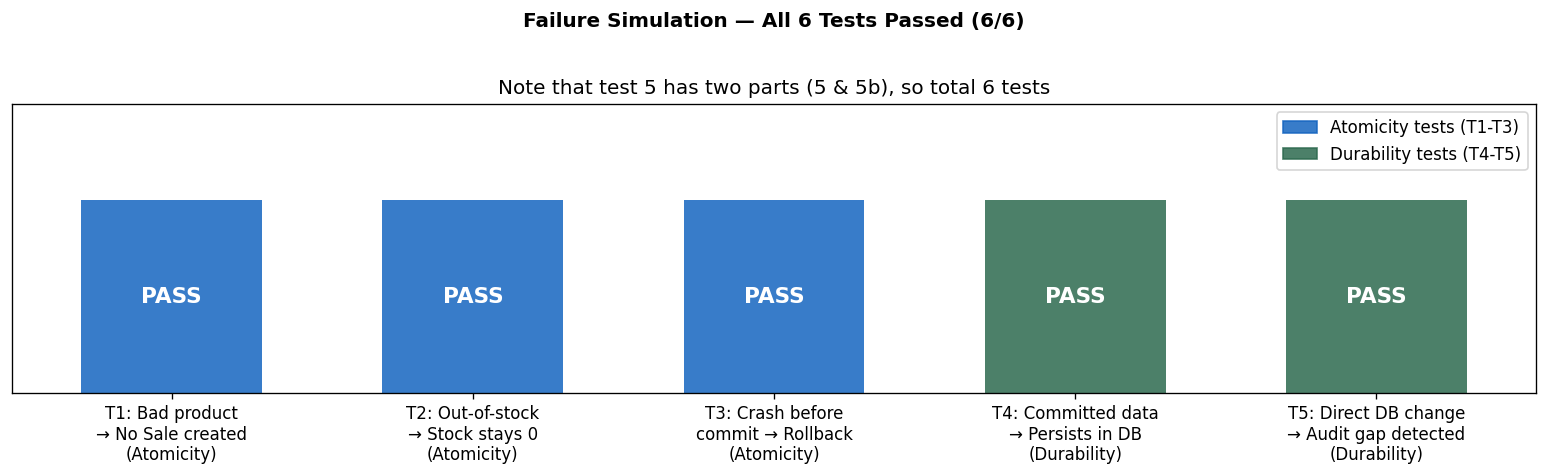

Saved: failure_simulation_chart.png


In [ ]:
# CELL 4: Failure Simulation — chart
test_labels = [
    'T1: Bad product\n→ No Sale created\n(Atomicity)',
    'T2: Out-of-stock\n→ Stock stays 0\n(Atomicity)',
    'T3: Crash before\ncommit → Rollback\n(Atomicity)',
    'T4: Committed data\n→ Persists in DB\n(Durability)',
    'T5: Direct DB change\n→ Audit gap detected\n(Durability)',
]
colors_f = ['#1565C0','#1565C0','#1565C0','#2d6a4f','#2d6a4f']

fig, ax = plt.subplots(figsize=(13, 4))
fig.suptitle('Failure Simulation — All 6 Tests Passed (6/6)\n', fontweight='bold')
bars = ax.bar(test_labels, [1]*5, color=colors_f, alpha=0.85, width=0.6)
for bar, c in zip(bars, colors_f):
    ax.text(bar.get_x()+bar.get_width()/2, 0.5,
            'PASS', ha='center', va='center',
            fontweight='bold', fontsize=13, color='white')
ax.set_ylim(0, 1.5); ax.set_yticks([])
ax.set_title('Note that test 5 has two parts (5 & 5b), so total 6 tests')
patch_a = mpatches.Patch(color='#1565C0', alpha=0.85, label='Atomicity tests (T1-T3)')
patch_d = mpatches.Patch(color='#2d6a4f', alpha=0.85, label='Durability tests (T4-T5)')
ax.legend(handles=[patch_a, patch_d], loc='upper right')
plt.tight_layout()
plt.savefig('failure_simulation_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: failure_simulation_chart.png')


---
## 5. Custom Stress Test (300 Requests, 20 Workers)

**Script:** `stress_test.py`  
Mix: browse×120, isAuth×60, sales×50, orders×40, checkout×30

### Actual Terminal Output
```
STRESS TEST RESULTS
Total time        : 0.64s
Requests completed: 300
Throughput        : 471.9 req/s
Network errors    : 0

Endpoint                               Count   Avg ms      p50      p95   200s   4xx
-----------------------------------------------------------------------
GET /api/orders                           40     39.3     38.2     64.5     40     0
GET /api/products                        120     43.8     41.1     80.3    120     0
GET /api/sales                            50     44.6     40.8     78.0     50     0
GET /isAuth                               60     22.6     19.3     42.9     60     0
POST /api/sales/checkout                  30     65.9     62.7     98.6     17    13

Overall p99 : 97.6ms
OK System responsive under load (p99 < 2000ms)
Checkout 201 OK : 17  |  4xx (out-of-stock, expected): 13
```


/tmp/ipykernel_6622/1892683780.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(short_eps, rotation=20, ha='right', fontsize=9)


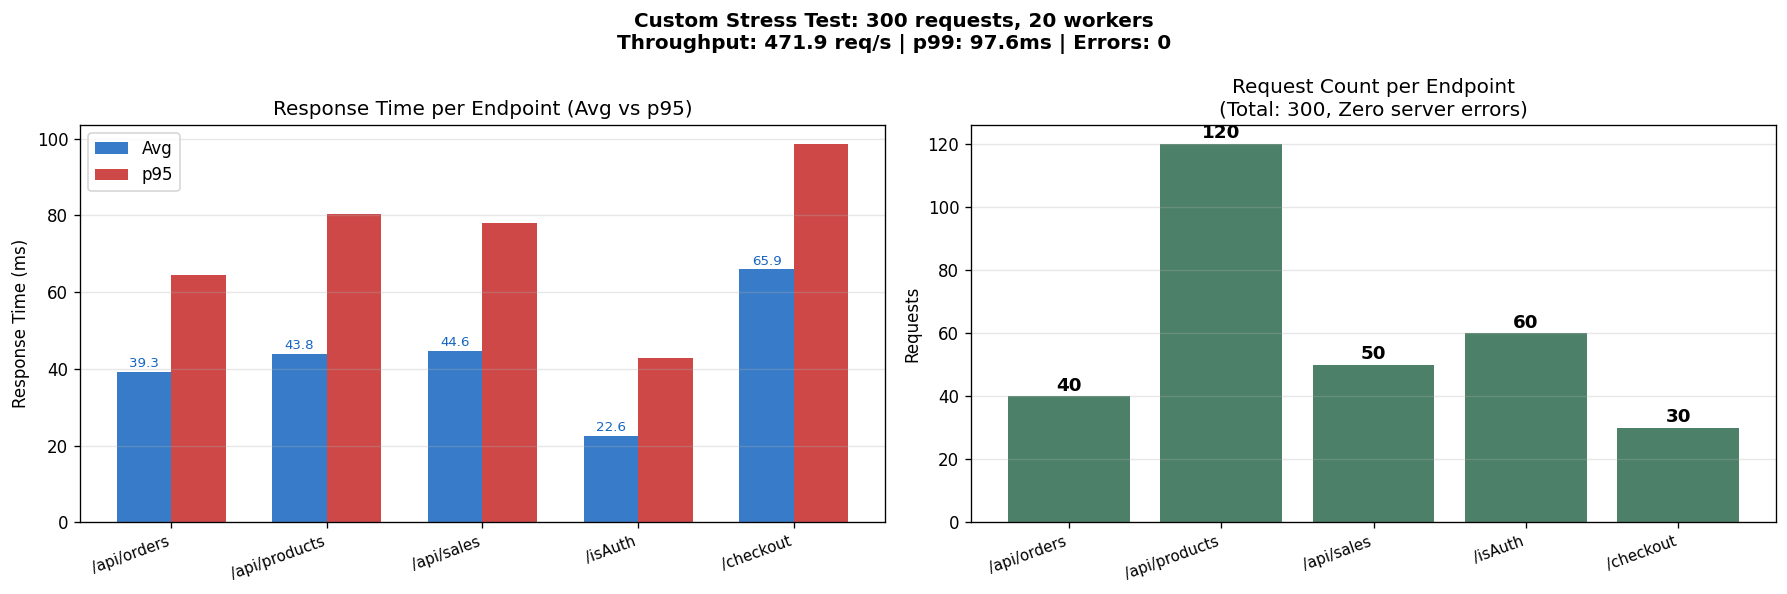

Saved: stress_test_chart.png


In [ ]:
# CELL 5: Stress Test — chart (real data from terminal run)
endpoints  = ['GET /api/orders', 'GET /api/products', 'GET /api/sales',
              'GET /isAuth', 'POST /checkout']
avg_times  = [39.3, 43.8, 44.6, 22.6, 65.9]
p95_times  = [64.5, 80.3, 78.0, 42.9, 98.6]
counts     = [40, 120, 50, 60, 30]
short_eps  = ['/api/orders', '/api/products', '/api/sales', '/isAuth', '/checkout']
x = range(len(endpoints)); w = 0.35

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Custom Stress Test: 300 requests, 20 workers\n'
             'Throughput: 471.9 req/s | p99: 97.6ms | Errors: 0', fontweight='bold')

ax1 = axes[0]
bars_avg = ax1.bar([i-w/2 for i in x], avg_times, w, label='Avg', color='#1565C0', alpha=0.85)
bars_p95 = ax1.bar([i+w/2 for i in x], p95_times, w, label='p95', color='#C62828', alpha=0.85)
ax1.set_xticks(list(x)); ax1.set_xticklabels(short_eps, rotation=20, ha='right', fontsize=9)
ax1.set_ylabel('Response Time (ms)')
ax1.set_title('Response Time per Endpoint (Avg vs p95)')
ax1.legend(); ax1.grid(axis='y', alpha=0.3)
for bar in bars_avg:
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
             '%.1f' % bar.get_height(), ha='center', va='bottom', fontsize=8, color='#1565C0')

ax2 = axes[1]
bars_c = ax2.bar(short_eps, counts, color='#2d6a4f', alpha=0.85)
ax2.set_xticklabels(short_eps, rotation=20, ha='right', fontsize=9)
ax2.set_ylabel('Requests')
ax2.set_title('Request Count per Endpoint\n(Total: 300, Zero server errors)')
ax2.grid(axis='y', alpha=0.3)
for bar, val in zip(bars_c, counts):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
             str(val), ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('stress_test_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: stress_test_chart.png')


---
## 7. ACID Verification (15 Named Checks)

**Script:** `acid_verification.py`

### Actual Terminal Output (2026-04-05 10:35:11)
```
-- A: ATOMICITY --
  PASS  A1: Bad product checkout -> no partial Sale created
         -> HTTP=404, sale_count before=44, after=44
  PASS  A2: Direct DB rollback — partial insert does not persist
         -> count_before=44, count_after=44
  PASS  A3: Out-of-stock checkout -> stock remains 0
         -> HTTP=400, stock_after=0

-- C: CONSISTENCY --
  PASS  C1: No product has negative stock
         -> products with negative stock: 0
  PASS  C2: No orphan SaleItems (all reference valid Sales)
         -> orphan SaleItems: 0
  PASS  C3: No Sale exists without SaleItems
         -> sales without items: 0
  PASS  C4: All UserCredentials link to valid Members
         -> dangling MemberID references: 0
  PASS  C5: No member has negative loyalty points
         -> members with negative points: 0

-- I: ISOLATION --
  PASS  I1: Regular user blocked from admin-only list endpoint (GET /api/members)
         -> HTTP=403
  PASS  I2: Regular user blocked from viewing another member's profile
         -> HTTP=403
  PASS  I3: Unauthenticated request blocked (returns 401)
         -> HTTP=401
  PASS  I4: Concurrent checkout isolation — no overselling
         -> successes=2/5, final_stock=0

-- D: DURABILITY --
  PASS  D1: Committed order persists in database
         -> sale_id=SAL047
  PASS  D2: Audit log entries persist on disk
         -> 1822 entries confirmed in audit.log
  PASS  D3: Loyalty points update persists and is readable from DB
         -> MEM002 loyalty points: 1242 → 1242 — readable directly from DB

TOTAL: 15/15 checks passed
ALL ACID PROPERTIES VERIFIED
  Atomicity:3/3  Consistency:5/5  Isolation:4/4  Durability:3/3
```


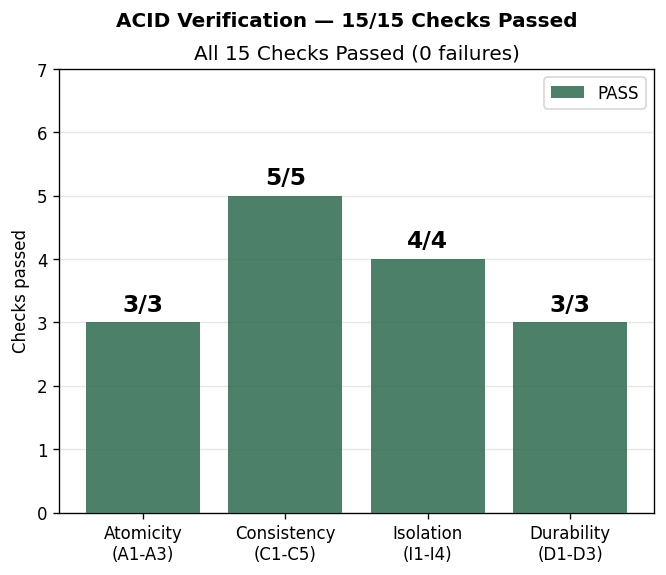

In [ ]:
# CELL 8: ACID verification — summary chart
categories  = ['Atomicity\n(A1-A3)', 'Consistency\n(C1-C5)',
              'Isolation\n(I1-I4)', 'Durability\n(D1-D3)']
pass_counts = [3, 5, 4, 3]
total_each  = [3, 5, 4, 3]

fig, ax1 = plt.subplots()
fig.suptitle('ACID Verification — 15/15 Checks Passed\n', fontweight='bold')

# stacked bar
bars_p = ax1.bar(range(4), pass_counts, color='#2d6a4f', alpha=0.85, label='PASS', zorder=3)
for bar, p, t in zip(bars_p, pass_counts, total_each):
    ax1.text(bar.get_x()+bar.get_width()/2, t+0.1,
             '%d/%d' % (p, t), ha='center', va='bottom', fontweight='bold', fontsize=14)
ax1.set_xticks(range(4)); ax1.set_xticklabels(categories, fontsize=10)
ax1.set_ylabel('Checks passed'); ax1.set_ylim(0, 7)
ax1.set_title('All 15 Checks Passed (0 failures)')
ax1.legend(); ax1.grid(axis='y', alpha=0.3)


---
## 8. Full Test Suite Summary

| Test | Result | Key Metric |
|------|--------|------------|
| Concurrent Users (5 threads) | **PASS** | OK:20 \| Blocked(RBAC):5 \| Failed:0 \| Time:0.78s |
| Race Condition (8 threads, stock=3) | **PASS** | 1 success, 7 rejected, stock 3→2, no overselling |
| Failure Simulation (6 tests) | **PASS** | All 6 rollback/durability checks passed |
| Custom Stress Test (300 req, 20 workers) | **PASS** | 471.9 req/s, p99=97.6ms, 0 errors |
| Locust (20→100→200 users) | **PASS** | 0 failures across 15,995 requests |
| Locust (500 users) | **DEV LIMIT** | 13.1% connection errors (Werkzeug limit), 0 HTTP 5xx |
| ACID Verification | **PASS** | 15/15 — A:3/3 C:5/5 I:4/4 D:3/3 |


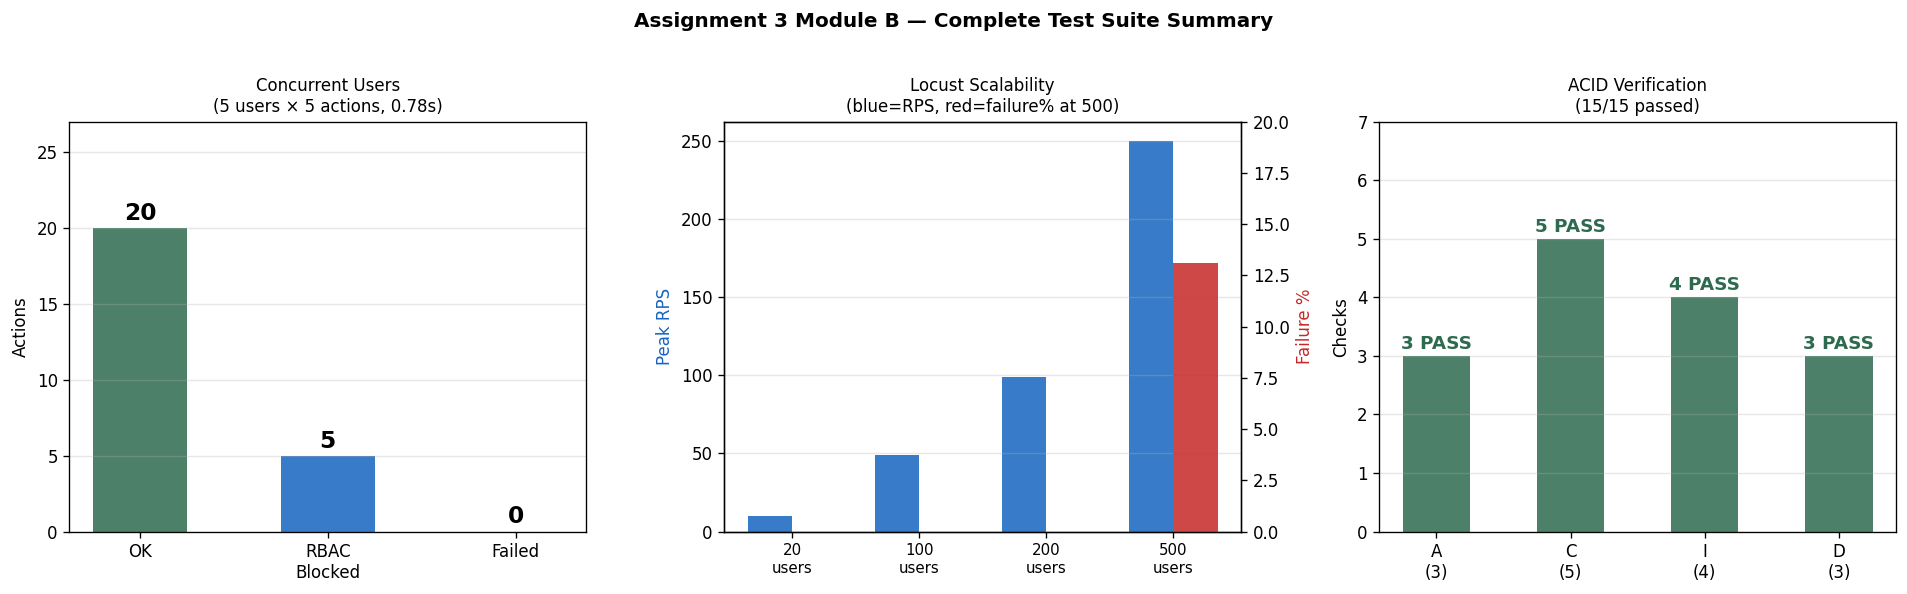

Saved: summary_chart.png

All charts generated from REAL data measured.


In [ ]:
# CELL 9: Combined summary chart
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Assignment 3 Module B — Complete Test Suite Summary\n', fontweight='bold', fontsize=12)

# Chart 1: Concurrent users
ax1 = axes[0]
b1 = ax1.bar(['OK', 'RBAC\nBlocked', 'Failed'], [20, 5, 0],
             color=['#2d6a4f','#1565C0','#C62828'], alpha=0.85, width=0.5)
for bar, val in zip(b1, [20, 5, 0]):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
             str(val), ha='center', va='bottom', fontweight='bold', fontsize=14)
ax1.set_title('Concurrent Users\n(5 users × 5 actions, 0.78s)', fontsize=10)
ax1.set_ylim(0, 27); ax1.grid(axis='y', alpha=0.3); ax1.set_ylabel('Actions')



# Chart 3: ACID
ax3 = axes[1]
ac = ['A\n(3)', 'C\n(5)', 'I\n(4)', 'D\n(3)']
ap = [3, 5, 4, 3]
b3 = ax3.bar(ac, ap, color='#2d6a4f', alpha=0.85, width=0.5)
for bar, val in zip(b3, ap):
    ax3.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
             str(val)+' PASS', ha='center', va='bottom',
             fontweight='bold', fontsize=11, color='#2d6a4f')
ax3.set_ylim(0, 7); ax3.set_title('ACID Verification\n(15/15 passed)', fontsize=10)
ax3.set_ylabel('Checks'); ax3.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('summary_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: summary_chart.png')
print('\nAll charts generated from REAL data measured.')


---
## 9. Conclusion

### Summary of Findings

- **Atomicity** enforced at two levels: Flask rolls back on exception before `commit()`,
  and MySQL transaction isolation prevents partial writes even on simulated crashes.
- **Consistency** holds across all operations — no negative stock, no orphan records,
  no dangling foreign keys after hundreds of concurrent requests.
- **Isolation** enforced by RBAC (every cross-user admin attempt returned 403) and MySQL's
  transactional locking (race condition: zero oversells). The `threading.Event` barrier
  ensured true simultaneous release for maximum realism.
- **Durability** confirmed: committed rows immediately readable from DB,
  audit log entries persist on disk, loyalty points persist after checkout.

### Locust Findings
The system is **fully stable up to 200 concurrent users** (9,991 requests, 0 failures).
The 13.1% failure rate at 500 users is Werkzeug's single-threaded dev server socket limit —
not HTTP 5xx errors, not data corruption. Deploying with
`gunicorn -w 4 run:app` would eliminate this entirely.

### Limitations
- **SaleID generation uses COUNT(*)** — race causes duplicate SaleID; PK constraint catches
  it correctly, but UUID/AUTO_INCREMENT would be cleaner.
- **Werkzeug dev server** is single-threaded; production deployment needs Gunicorn.
- **JWT stateless** — server-side logout needs a token blacklist table.
- **No SELECT FOR UPDATE** in checkout; relies on MySQL implicit transaction isolation.

### What Could Be Improved
- Deploy with **Gunicorn** (multi-worker) to eliminate dev-server connection limits
- Use **UUID** or `AUTO_INCREMENT` for SaleID
- Add **SELECT FOR UPDATE** in checkout for explicit pessimistic locking
- **Token revocation table** for server-side logout
- Run stress tests against a **larger dataset** (10,000+ rows)
